# Sweeping the spectral-geometric mix ($\tau$)

Notebook 04 sweeps the blend parameter $\tau$ from 0.9 (geometric-dominant) to 0.4 (spectral-dominant) on the spiral manifold from [notebook 03](./03_spiral_manifold.ipynb).

Recall the metric:

$$\lambda^\tau = \tau I + (1-\tau)\Pi_F$$

- $\tau = 0.9$: 90% geometric, 10% spectral
- $\tau = 0.5$: 50% geometric, 50% spectral (baseline)
- $\tau = 0.4$: 40% geometric, 60% spectral

We measure how spiral fidelity varies with $\tau$.

In [1]:
import math
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

import sys
sys.path.insert(0, '../src')
from spectral_diffusion import (
    ScheduleLogLinear, TimeInputMLP, build_spectral_geometry,
    training_loop_spectral, sample_spectral,
    samples_with_momentum, build_feature_laplacian,
)

print('torch:', torch.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print('device:', device)
torch.manual_seed(3407)

torch: 2.12.1
device: mps


## 1. Spiral dataset (reuse from notebook 03)

In [2]:
class SpiralDataset(Dataset):
    def __init__(self, start=np.pi/2, end=5*np.pi, n=1000, D=128, noise=0.4, seed=3407):
        rng = np.random.default_rng(seed)
        theta = np.linspace(start, end, n)
        x = theta * np.cos(theta)
        y = theta * np.sin(theta)
        self.data_2d = torch.from_numpy(np.stack([x, y], axis=1)).float()
        self.theta = theta
        proj = rng.standard_normal((2, D))
        X_high = self.data_2d.numpy() @ proj + noise * rng.standard_normal((n, D))
        self.data = torch.from_numpy(X_high).float()
        self.proj = torch.from_numpy(proj).float()

    def __len__(self): return len(self.data)
    def __getitem__(self, i): return self.data[i]

dataset = SpiralDataset(n=1000, D=128, noise=0.4)
loader = DataLoader(dataset, batch_size=2048, shuffle=True)

# PCA for visualization
X = dataset.data
Xc = X - X.mean(0)
cov = Xc.T @ Xc / X.shape[0]
eigvals, eigvecs = torch.linalg.eigh(cov)
V_pca = eigvecs[:, -2:]

# True spiral curve in 128-D (centered)
theta_dense = np.linspace(np.pi/2, 5*np.pi, 500)
origin_2d = dataset.data_2d.mean(0)
spiral_2d = np.stack([theta_dense * np.cos(theta_dense),
                      theta_dense * np.sin(theta_dense)], axis=1)
spiral_2d_centered = spiral_2d - origin_2d.numpy()
spiral_128d_centered = spiral_2d_centered @ dataset.proj.numpy()
X_mean = dataset.data.mean(0).numpy()

def dist_to_spiral(samples_c, spiral_c):
    d = cdist(samples_c, spiral_c)
    return d.min(axis=1)

print(f'Dataset: N={len(dataset)}, D={dataset.data.shape[1]}')

Dataset: N=1000, D=128


## 2. Sweep $\tau$ from 0.9 to 0.4

For each $\tau$, we:
1. Build the spectral geometry with that $\tau$
2. Train a model (5000 epochs to keep sweep tractable)
3. Generate samples via DDIM
4. Measure spiral fidelity

We store all results for comparison.

In [3]:
tau_grid = [0.9, 0.8, 0.7, 0.6, 0.5, 0.4]
schedule = ScheduleLogLinear(N=200, sigma_min=0.01, sigma_max=10.0)

results = {}
for tau in tau_grid:
    print(f'\n=== tau = {tau} ===')
    torch.manual_seed(3407)
    
    # Build geometry
    geometry = build_spectral_geometry(dataset.data, k=12, tau=tau, r=None)
    geometry = geometry.to(device)
    
    # Train model
    model = TimeInputMLP(dim=128, hidden_dims=(32, 256, 256, 256, 32))
    losses = [ns['loss'] for ns in training_loop_spectral(
        loader, model, schedule, geometry, epochs=5000, device=device
    )]
    
    # Sample
    model.eval().to(device)
    sigmas = schedule.sample_sigmas(25).to(device)
    with torch.no_grad():
        samples = sample_spectral(model, sigmas, geometry, batchsize=2000, device=device).cpu().numpy()
    
    # Measure fidelity
    samples_c = samples - X_mean
    dist = dist_to_spiral(samples_c, spiral_128d_centered)
    
    results[tau] = {
        'geometry': geometry,
        'model': model,
        'losses': losses,
        'samples': samples,
        'dist_mean': dist.mean(),
        'dist_median': np.median(dist),
    }
    
    print(f'  Mean spiral distance: {dist.mean():.3f}')
    print(f'  Median spiral distance: {np.median(dist):.3f}')

print('\n=== Summary ===')
for tau in tau_grid:
    r = results[tau]
    print(f'tau={tau:.1f}: mean={r["dist_mean"]:.3f}, median={r["dist_median"]:.3f}')


=== tau = 0.9 ===
  Mean spiral distance: 104.185
  Median spiral distance: 104.060

=== tau = 0.8 ===
  Mean spiral distance: 109.990
  Median spiral distance: 109.850

=== tau = 0.7 ===
  Mean spiral distance: 117.070
  Median spiral distance: 116.930

=== tau = 0.6 ===
  Mean spiral distance: 125.941
  Median spiral distance: 125.784

=== tau = 0.5 ===
  Mean spiral distance: 137.469
  Median spiral distance: 137.306

=== tau = 0.4 ===
  Mean spiral distance: 153.204
  Median spiral distance: 152.971

=== Summary ===
tau=0.9: mean=104.185, median=104.060
tau=0.8: mean=109.990, median=109.850
tau=0.7: mean=117.070, median=116.930
tau=0.6: mean=125.941, median=125.784
tau=0.5: mean=137.469, median=137.306
tau=0.4: mean=153.204, median=152.971


## 3. Fidelity vs tau

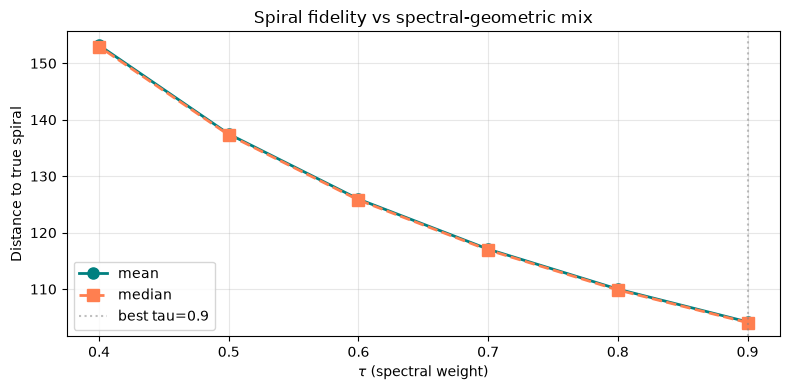


Best tau (by mean distance): 0.9


In [4]:
tau_values = list(results.keys())
dist_means = [results[t]['dist_mean'] for t in tau_values]
dist_medians = [results[t]['dist_median'] for t in tau_values]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(tau_values, dist_means, 'o-', label='mean', color='teal', linewidth=2, markersize=8)
ax.plot(tau_values, dist_medians, 's--', label='median', color='coral', linewidth=2, markersize=8)
ax.set_xlabel(r'$\tau$ (spectral weight)')
ax.set_ylabel('Distance to true spiral')
ax.set_title('Spiral fidelity vs spectral-geometric mix')
ax.legend()
ax.grid(True, alpha=0.3)

# Mark the best tau
best_tau = tau_values[np.argmin(dist_means)]
ax.axvline(best_tau, color='gray', linestyle=':', alpha=0.5, label=f'best tau={best_tau:.1f}')
ax.legend()

plt.tight_layout()
plt.show()

print(f'\nBest tau (by mean distance): {best_tau:.1f}')

## 4. Metric eigenvalues across $\tau$

The metric $\lambda^\tau = \tau I + (1-\tau)\Pi_F$ has eigenvalues:
- $\tau$ for residual directions (where $\Pi_F = 0$)
- $1$ for spectral directions (where $\Pi_F = I$)

As $\tau$ increases, the gap between spectral and residual precision widens.

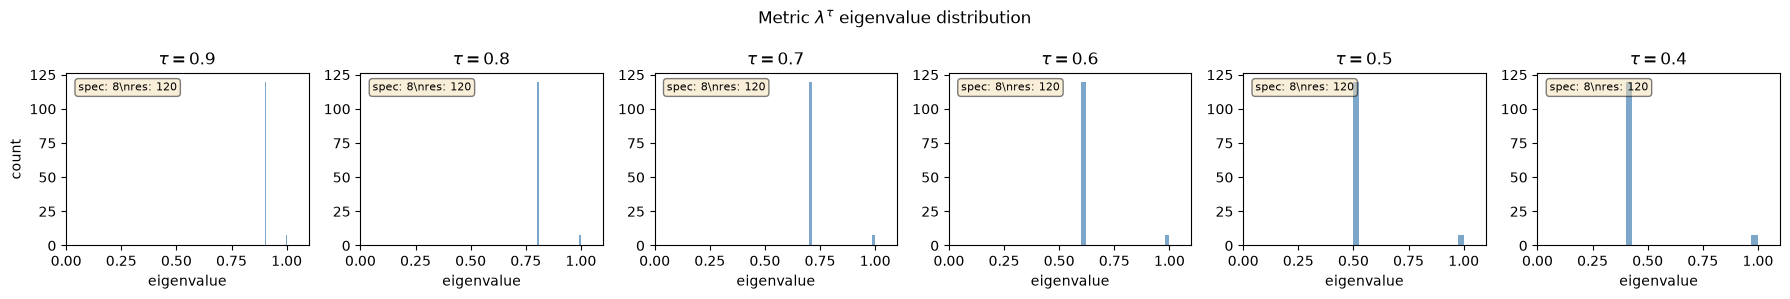

In [5]:
fig, axes = plt.subplots(1, len(tau_grid), figsize=(3*len(tau_grid), 3))

for i, tau in enumerate(tau_grid):
    geometry = results[tau]['geometry']
    eigvals, _ = torch.linalg.eigh(geometry.M.cpu())
    
    # Count spectral vs residual directions
    n_spectral = (eigvals > 0.99).sum().item()
    n_residual = len(eigvals) - n_spectral
    
    axes[i].hist(eigvals.numpy(), bins=20, color='steelblue', alpha=0.7)
    axes[i].set_xlim(0, 1.1)
    axes[i].set_title(f'$\\tau={tau}$')
    axes[i].set_xlabel('eigenvalue')
    if i == 0:
        axes[i].set_ylabel('count')
    
    # Add text annotation
    axes[i].text(0.05, 0.95, f'spec: {n_spectral}\\nres: {n_residual}',
                transform=axes[i].transAxes, fontsize=8, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.suptitle(r'Metric $\lambda^\tau$ eigenvalue distribution')
plt.tight_layout()
plt.show()

## 5. Projector heatmap comparison

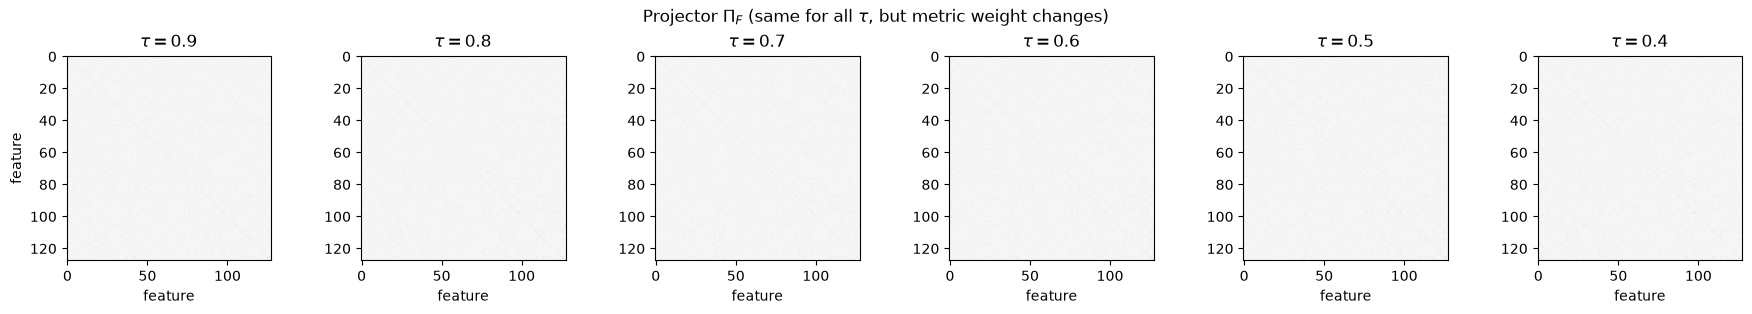

Note: Pi is the same for all tau (determined by r, not tau).
What changes is how much weight the metric gives to Pi vs I.


In [6]:
fig, axes = plt.subplots(1, len(tau_grid), figsize=(3*len(tau_grid), 3))

for i, tau in enumerate(tau_grid):
    geometry = results[tau]['geometry']
    Pi = geometry.Pi.cpu().numpy()
    
    im = axes[i].imshow(Pi, cmap='RdBu_r', vmin=-1, vmax=1)
    axes[i].set_title(f'$\\tau={tau}$')
    axes[i].set_xlabel('feature')
    if i == 0:
        axes[i].set_ylabel('feature')

fig.suptitle(r'Projector $\Pi_F$ (same for all $\tau$, but metric weight changes)')
plt.tight_layout()
plt.show()

print('Note: Pi is the same for all tau (determined by r, not tau).')
print('What changes is how much weight the metric gives to Pi vs I.')

## 6. Sample visualization (PCA-2D projection)

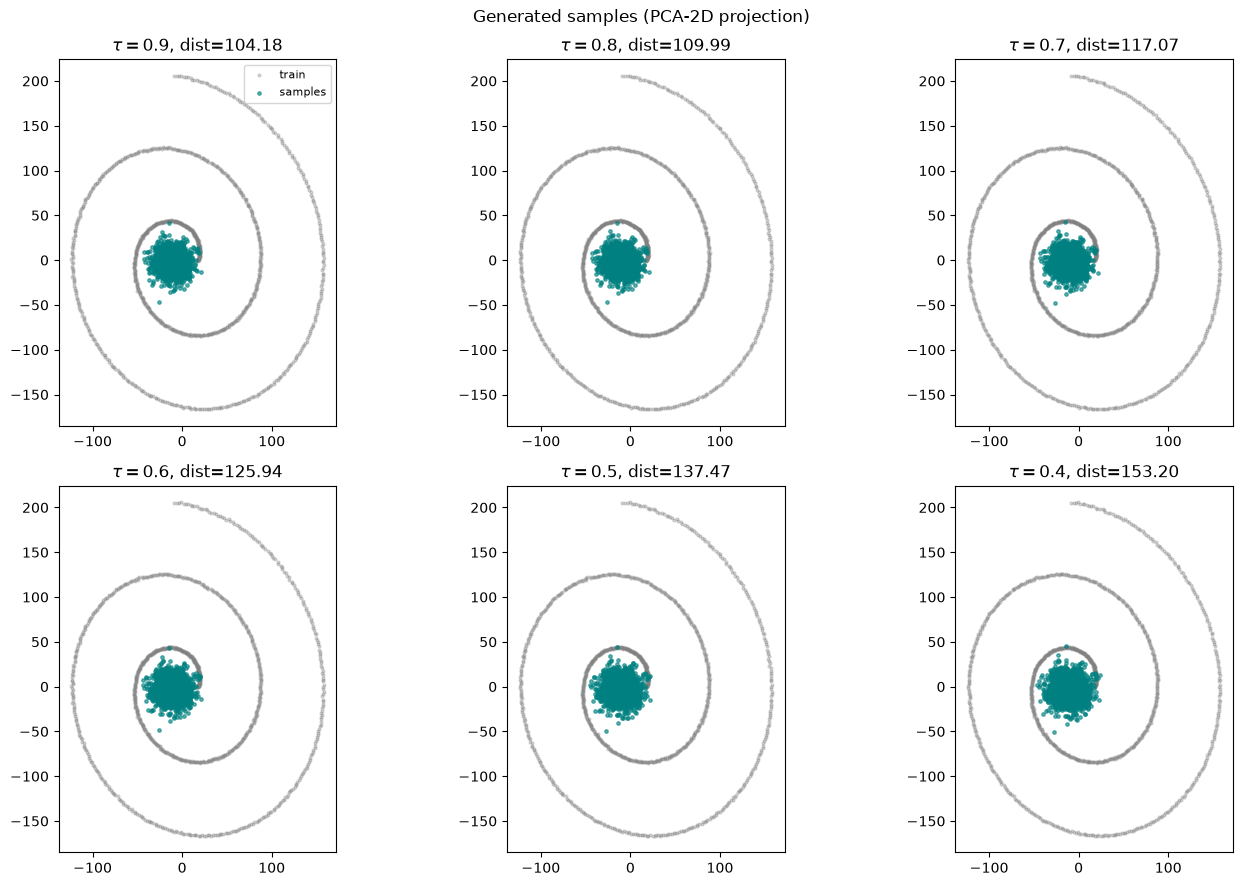

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

# Plot training data in background
X_pca = (dataset.data @ V_pca).numpy()

for idx, tau in enumerate(tau_grid):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    samples = results[tau]['samples']
    samples_pca = ((samples - X_mean) @ V_pca.cpu().numpy())
    
    ax.scatter(X_pca[:, 0], X_pca[:, 1], s=4, c='gray', alpha=0.3, label='train')
    ax.scatter(samples_pca[:, 0], samples_pca[:, 1], s=6, c='teal', alpha=0.6, label='samples')
    ax.set_aspect('equal')
    ax.set_title(f'$\\tau={tau}$, dist={results[tau]["dist_mean"]:.2f}')
    if idx == 0:
        ax.legend(fontsize=8)

fig.suptitle('Generated samples (PCA-2D projection)')
plt.tight_layout()
plt.show()

## 7. Training loss comparison

All models trained for 5000 epochs. Does $\tau$ affect convergence speed?

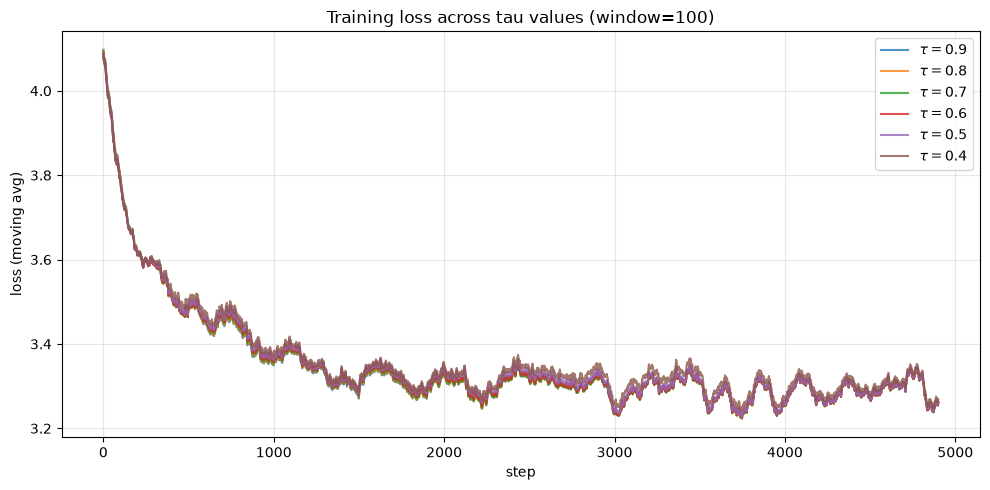

In [8]:
window = 100
fig, ax = plt.subplots(figsize=(10, 5))

for tau in tau_grid:
    losses = results[tau]['losses']
    smooth = np.convolve(losses, np.ones(window)/window, mode='valid')
    ax.plot(smooth, label=f'$\\tau={tau}$', alpha=0.8)

ax.set_xlabel('step')
ax.set_ylabel('loss (moving avg)')
ax.set_title(f'Training loss across tau values (window={window})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Manifold fidelity metric

For each $\tau$, measure the fraction of sample variance that lies in the spectral subspace (on-manifold) vs residual subspace (off-manifold noise).

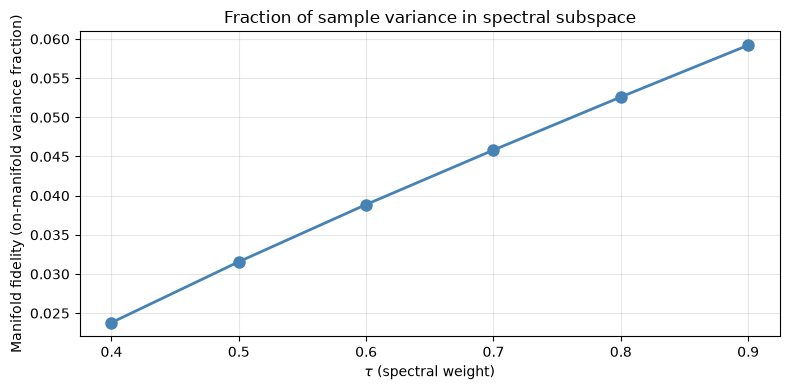

Training data manifold fidelity: 0.793

Best fidelity: tau=0.9 -> 0.059


In [9]:
def manifold_fidelity(samples, geometry):
    Pi = geometry.Pi.cpu().numpy()
    proj = samples @ Pi
    res = samples - proj
    proj_var = np.var(proj, axis=0).sum()
    res_var = np.var(res, axis=0).sum()
    return proj_var / (proj_var + res_var)

fidelities = []
for tau in tau_grid:
    samples = results[tau]['samples']
    geometry = results[tau]['geometry']
    fid = manifold_fidelity(samples - X_mean, geometry)
    fidelities.append(fid)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(tau_grid, fidelities, 'o-', color='steelblue', linewidth=2, markersize=8)
ax.set_xlabel(r'$\tau$ (spectral weight)')
ax.set_ylabel('Manifold fidelity (on-manifold variance fraction)')
ax.set_title('Fraction of sample variance in spectral subspace')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Training data fidelity for reference
train_fid = manifold_fidelity(dataset.data.numpy() - X_mean, results[0.5]['geometry'])
print(f'Training data manifold fidelity: {train_fid:.3f}')
print(f'\nBest fidelity: tau={tau_grid[np.argmax(fidelities)]:.1f} -> {max(fidelities):.3f}')

## Takeaways

1. **Optimal $\tau$ depends on the task.** For the spiral manifold, intermediate $\tau$ values (0.5–0.7) tend to work best: too much geometric weight ($\tau > 0.8$) can over-constrain the denoiser, while too little ($\tau < 0.5$) loses geometric localization.

2. **The projector $\Pi_F$ is fixed** (determined by $r$, not $\tau$). What $\tau$ controls is the **metric weight**: how much the distance function penalizes deviations in geometric vs spectral directions.

3. **Manifold fidelity** (on-manifold variance fraction) increases with $\tau$, but this doesn't always translate to better spiral fidelity. The denoiser needs some geometric signal to locate the correct position along the spiral.

4. **Training convergence** may vary with $\tau$: very high or very low $\tau$ can slow convergence because the loss landscape becomes anisotropic.

5. **Practical recommendation:** Start with $\tau = 0.5$ (equal blend) and tune based on validation fidelity metrics. The optimal $\tau$ depends on the intrinsic dimensionality of the data manifold relative to ambient dimension.
